In [ ]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [ ]:
# Loading the dataset
df=pd.read_csv("/content/StockPriceDataset.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2014-01-02,19.845715,19.893929,19.715000,19.754642,17.273226,234684800,AAPL
1,2014-01-03,19.745001,19.775000,19.301071,19.320715,16.893808,392467600,AAPL
2,2014-01-06,19.194643,19.528570,19.057142,19.426071,16.985926,412610800,AAPL
3,2014-01-07,19.440001,19.498571,19.211430,19.287144,16.864458,317209200,AAPL
4,2014-01-08,19.243214,19.484285,19.238930,19.409286,16.971254,258529600,AAPL


In [ ]:
# Parse date column and set as index
df['Date']= pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Only use the 'Close' price
data=df['Close']

print(data.head())

Date
2014-01-02    19.754642
2014-01-03    19.320715
2014-01-06    19.426071
2014-01-07    19.287144
2014-01-08    19.409286
Name: Close, dtype: float64


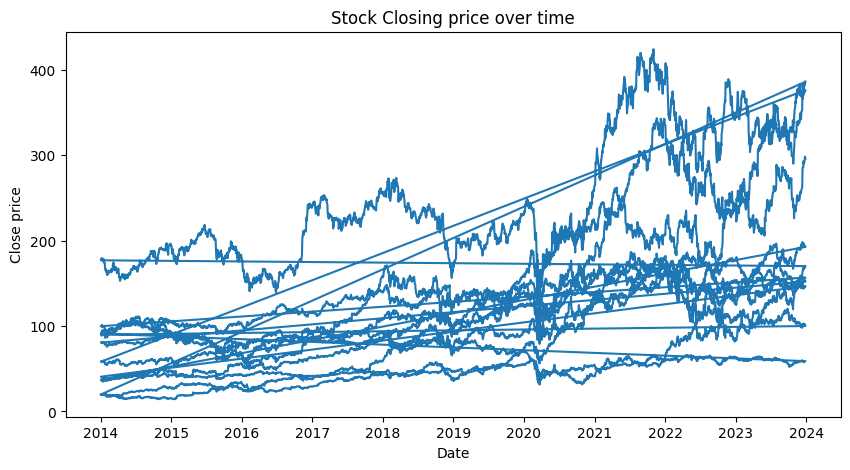

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(data)
plt.title('Stock Closing price over time')
plt.xlabel("Date")
plt.ylabel("Close price")
plt.show()

In [ ]:
train_size=int(len(data)*0.8)
train_data= data[:train_size]
test_data= data[train_size:]

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsm

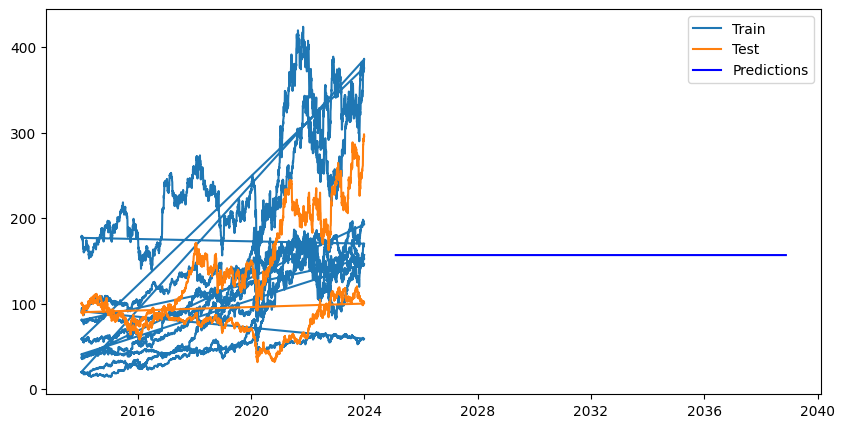

In [ ]:
# Fit an ARIMA model
model=ARIMA(train_data, order=(5,1,0))
model_fit=model.fit()

# Predict
start=len(train_data)
end=len(train_data)+len(test_data)-1
predictions=model_fit.predict(start=start, end=end)

# Plot prediction vs actual
plt.figure(figsize=(10,5))
plt.plot(train_data, label='Train')
plt.plot(test_data, label='Test')
plt.plot(predictions, label='Predictions', color='blue')
plt.legend()
plt.show()

In [ ]:
# RMSE evaluation
rmse=np.sqrt(mean_squared_error(test_data, predictions))
print(f"RMSE: {rmse:2f}")

RMSE: 69.377570
